# 特征生成

In [2]:
import os
import numpy as np
import pandas as pd
import re
import warnings
import time

# 导入 matminer 和其底层库 pymatgen
try:
    from matminer.featurizers.composition import ElementProperty
    from pymatgen.core import Composition
    MATMINER_AVAILABLE = True
except ImportError:
    MATMINER_AVAILABLE = False
    ElementProperty = None
    Composition = None
    print("⚠️ 警告：matminer 或其依赖库（如 pymatgen）未安装。Matminer 特征将无法生成。")

# --- 扩展原子属性 (新增价电子数和混合焓所需的属性) ---
ATOMIC_PROPS = {
    # mass, radius (A), eneg (Pauling), group, period, valence (常见价电子), H_mix_param (用于简化模型)
    'Ag': {'mass': 107.87, 'radius': 1.65, 'eneg': 1.93, 'group': 11, 'period': 5, 'valence': 1, 'H_mix_param': 0.155},
    'Al': {'mass': 26.98, 'radius': 1.18, 'eneg': 1.61, 'group': 13, 'period': 3, 'valence': 3, 'H_mix_param': 0.137},
    'As': {'mass': 74.92, 'radius': 1.19, 'eneg': 2.18, 'group': 15, 'period': 4, 'valence': 5, 'H_mix_param': 0.150},
    'Au': {'mass': 196.97, 'radius': 1.74, 'eneg': 2.54, 'group': 11, 'period': 6, 'valence': 3, 'H_mix_param': 0.145},
    'B':  {'mass': 10.81, 'radius': 0.85, 'eneg': 2.04, 'group': 13, 'period': 2, 'valence': 3, 'H_mix_param': 0.140},
    'Ba': {'mass': 137.33, 'radius': 2.15, 'eneg': 0.89, 'group': 2, 'period': 6, 'valence': 2, 'H_mix_param': 0.125},
    'Bi': {'mass': 208.98, 'radius': 1.63, 'eneg': 2.02, 'group': 15, 'period': 6, 'valence': 5, 'H_mix_param': 0.147},
    'Br': {'mass': 79.90, 'radius': 1.14, 'eneg': 2.96, 'group': 17, 'period': 4, 'valence': 7, 'H_mix_param': 0.160},
    'Ca': {'mass': 40.08, 'radius': 1.94, 'eneg': 1.00, 'group': 2, 'period': 4, 'valence': 2, 'H_mix_param': 0.128},
    'Cd': {'mass': 112.41, 'radius': 1.49, 'eneg': 1.69, 'group': 12, 'period': 5, 'valence': 2, 'H_mix_param': 0.143},
    'Cl': {'mass': 35.45, 'radius': 0.79, 'eneg': 3.16, 'group': 17, 'period': 3, 'valence': 7, 'H_mix_param': 0.165},
    'Co': {'mass': 58.93, 'radius': 1.25, 'eneg': 1.88, 'group': 9, 'period': 4, 'valence': 3, 'H_mix_param': 0.145},
    'Cr': {'mass': 52.00, 'radius': 1.28, 'eneg': 1.66, 'group': 6, 'period': 4, 'valence': 3, 'H_mix_param': 0.139},
    'Cu': {'mass': 63.55, 'radius': 1.28, 'eneg': 1.90, 'group': 11, 'period': 4, 'valence': 2, 'H_mix_param': 0.148},
    'Fe': {'mass': 55.85, 'radius': 1.26, 'eneg': 1.83, 'group': 8, 'period': 4, 'valence': 3, 'H_mix_param': 0.142},
    'Ga': {'mass': 69.72, 'radius': 1.36, 'eneg': 1.81, 'group': 13, 'period': 4, 'valence': 3, 'H_mix_param': 0.141},
    'Ge': {'mass': 72.63, 'radius': 1.22, 'eneg': 2.01, 'group': 14, 'period': 4, 'valence': 4, 'H_mix_param': 0.146},
    'Hf': {'mass': 178.49, 'radius': 1.59, 'eneg': 1.3, 'group': 4, 'period': 6, 'valence': 4, 'H_mix_param': 0.135},
    'I':  {'mass': 126.90, 'radius': 1.39, 'eneg': 2.66, 'group': 17, 'period': 5, 'valence': 7, 'H_mix_param': 0.158},
    'In': {'mass': 114.82, 'radius': 1.67, 'eneg': 1.78, 'group': 13, 'period': 5, 'valence': 3, 'H_mix_param': 0.140},
    'K':  {'mass': 39.10, 'radius': 2.27, 'eneg': 0.82, 'group': 1, 'period': 4, 'valence': 1, 'H_mix_param': 0.120},
    'Li': {'mass': 6.94, 'radius': 1.67, 'eneg': 0.98, 'group': 1, 'period': 2, 'valence': 1, 'H_mix_param': 0.115},
    'Mg': {'mass': 24.31, 'radius': 1.50, 'eneg': 1.31, 'group': 2, 'period': 3, 'valence': 2, 'H_mix_param': 0.132},
    'Mn': {'mass': 54.94, 'radius': 1.27, 'eneg': 1.55, 'group': 7, 'period': 4, 'valence': 2, 'H_mix_param': 0.138},
    'Mo': {'mass': 95.96, 'radius': 1.39, 'eneg': 2.16, 'group': 6, 'period': 5, 'valence': 6, 'H_mix_param': 0.145},
    'N':  {'mass': 14.01, 'radius': 0.75, 'eneg': 3.04, 'group': 15, 'period': 2, 'valence': 5, 'H_mix_param': 0.160},
    'Na': {'mass': 22.99, 'radius': 1.90, 'eneg': 0.93, 'group': 1, 'period': 3, 'valence': 1, 'H_mix_param': 0.122},
    'Nb': {'mass': 92.91, 'radius': 1.46, 'eneg': 1.6, 'group': 5, 'period': 5, 'valence': 5, 'H_mix_param': 0.138},
    'Ni': {'mass': 58.69, 'radius': 1.24, 'eneg': 1.91, 'group': 10, 'period': 4, 'valence': 2, 'H_mix_param': 0.146},
    'O':  {'mass': 16.00, 'radius': 0.73, 'eneg': 3.44, 'group': 16, 'period': 2, 'valence': 6, 'H_mix_param': 0.170},
    'P':  {'mass': 30.97, 'radius': 1.10, 'eneg': 2.19, 'group': 15, 'period': 3, 'valence': 5, 'H_mix_param': 0.152},
    'Pb': {'mass': 207.20, 'radius': 1.80, 'eneg': 2.33, 'group': 14, 'period': 6, 'valence': 4, 'H_mix_param': 0.150},
    'Pd': {'mass': 106.42, 'radius': 1.37, 'eneg': 2.20, 'group': 10, 'period': 5, 'valence': 4, 'H_mix_param': 0.150},
    'Rb': {'mass': 85.47, 'radius': 2.48, 'eneg': 0.82, 'group': 1, 'period': 5, 'valence': 1, 'H_mix_param': 0.120},
    'Ru': {'mass': 101.07, 'radius': 1.34, 'eneg': 2.20, 'group': 8, 'period': 5, 'valence': 3, 'H_mix_param': 0.145},
    'S':  {'mass': 32.07, 'radius': 1.02, 'eneg': 2.58, 'group': 16, 'period': 3, 'valence': 6, 'H_mix_param': 0.155},
    'Sb': {'mass': 121.76, 'radius': 1.39, 'eneg': 2.05, 'group': 15, 'period': 5, 'valence': 5, 'H_mix_param': 0.148},
    'Sc': {'mass': 44.96, 'radius': 1.62, 'eneg': 1.36, 'group': 3, 'period': 4, 'valence': 3, 'H_mix_param': 0.135},
    'Se': {'mass': 78.96, 'radius': 1.19, 'eneg': 2.55, 'group': 16, 'period': 4, 'valence': 6, 'H_mix_param': 0.157},
    'Si': {'mass': 28.09, 'radius': 1.11, 'eneg': 1.90, 'group': 14, 'period': 3, 'valence': 4, 'H_mix_param': 0.145},
    'Sn': {'mass': 118.71, 'radius': 1.45, 'eneg': 1.96, 'group': 14, 'period': 5, 'valence': 4, 'H_mix_param': 0.144},
    'Sr': {'mass': 87.62, 'radius': 2.15, 'eneg': 0.95, 'group': 2, 'period': 5, 'valence': 2, 'H_mix_param': 0.127},
    'Ta': {'mass': 180.95, 'radius': 1.43, 'eneg': 1.5, 'group': 5, 'period': 6, 'valence': 5, 'H_mix_param': 0.137},
    'Te': {'mass': 127.60, 'radius': 1.42, 'eneg': 2.10, 'group': 16, 'period': 5, 'valence': 6, 'H_mix_param': 0.150},
    'Ti': {'mass': 47.87, 'radius': 1.47, 'eneg': 1.54, 'group': 4, 'period': 4, 'valence': 4, 'H_mix_param': 0.136},
    'Tl': {'mass': 204.38, 'radius': 1.70, 'eneg': 1.62, 'group': 13, 'period': 6, 'valence': 3, 'H_mix_param': 0.140},
    'V':  {'mass': 50.94, 'radius': 1.34, 'eneg': 1.63, 'group': 5, 'period': 4, 'valence': 5, 'H_mix_param': 0.138},
    'Y':  {'mass': 88.91, 'radius': 1.77, 'eneg': 1.22, 'group': 3, 'period': 5, 'valence': 3, 'H_mix_param': 0.130},
    'Zn': {'mass': 65.38, 'radius': 1.34, 'eneg': 1.65, 'group': 12, 'period': 4, 'valence': 2, 'H_mix_param': 0.140},
    'Zr': {'mass': 91.22, 'radius': 1.59, 'eneg': 1.33, 'group': 4, 'period': 5, 'valence': 4, 'H_mix_param': 0.135},
}

# --- 1. 公式解析函数 (用于计算原子比) ---
def parse_formula(formula):
    composition = {}
    def expand_paren(match):
        content, factor = match.groups()
        factor = float(factor) if factor else 1.0
        # 匹配元素和可能的数字
        sub_matches = re.findall(r'([A-Z][a-z]*)(\d*\.?\d*)', content)
        expanded_parts = []
        for element, count in sub_matches:
            original_count = float(count) if count else 1.0
            new_count = original_count * factor
            expanded_parts.append(f"{element}{new_count}")
        return "".join(expanded_parts)
    
    # 先处理括号
    expanded_formula = re.sub(r'\((.*?)\)(\d*\.?\d*)', expand_paren, formula)
    # 再解析最终的元素和原子数
    final_matches = re.findall(r'([A-Z][a-z]*)(\d*\.?\d*)', expanded_formula)
    
    for element, count in final_matches:
        count = float(count) if count else 1.0
        composition[element] = composition.get(element, 0.0) + count
    return composition

# 辅助函数：将 wt% 字符串标准化为 matminer 能识别的格式（如 Cu80O20）
def wtpercentstr_to_formula(wt_str):
    if pd.isnull(wt_str):
        return ""
    # 去除分隔符，只保留元素符号和数字
    s = str(wt_str).replace(";", "").replace(":", "").replace(",", "")
    return s.strip()

# --- 2. 核心特征计算函数 ---

def calculate_manual_features(df, all_elements, ratio_series_dict, total_atoms_series):
    features = {}
    
    # 计算平均属性 (用于方差计算)
    def safe_mean(weighted_sum, total_atoms):
        # 确保返回一维数组
        result = np.where(total_atoms > 0, weighted_sum / total_atoms, 0.0)
        return result.flatten() if result.ndim > 1 else result

    properties = ['mass', 'radius', 'eneg', 'valence']
    weighted_sums = {p: 0.0 for p in properties}
    
    for element in all_elements:
        if element in ATOMIC_PROPS:
            prop = ATOMIC_PROPS[element]
            ratio = ratio_series_dict[element]
            for p in properties:
                # 累加 c_i * P_i (原子数加权的属性值之和)
                weighted_sums[p] += ratio * prop[p]

    avg_prop = {p: safe_mean(weighted_sums[p], total_atoms_series) for p in properties}

    # 1. 方差 (Variance, $\sigma^2$): $\sum c_i (P_i - \bar{P})^2 / \sum c_i$
    def calculate_variance(prop_name, avg_series):
        diff_sq_series = 0.0
        for element in all_elements:
            if element in ATOMIC_PROPS:
                prop_val = ATOMIC_PROPS[element][prop_name]
                ratio = ratio_series_dict[element]
                # 累加 c_i * (P_i - \bar{P})^2
                diff_sq_series += ratio * (prop_val - avg_series)**2
        
        # 标准化为方差，并确保返回一维数组
        result = np.where(total_atoms_series > 0, diff_sq_series / total_atoms_series, 0.0)
        return result.flatten() if result.ndim > 1 else result

    features['Mass_variance'] = calculate_variance('mass', avg_prop['mass'])
    features['Radius_variance'] = calculate_variance('radius', avg_prop['radius'])
    features['Valence_mean'] = avg_prop['valence']
    features['Valence_variance'] = calculate_variance('valence', avg_prop['valence'])

    # 2. 极差 (Range)
    # 极差需要逐行计算
    def calculate_range(prop_name, composition):
        vals = [ATOMIC_PROPS[el][prop_name] for el, ratio in composition.items() if ratio > 0 and el in ATOMIC_PROPS]
        return (max(vals) - min(vals)) if vals else 0.0

    features['Eneg_range'] = df['Composition'].apply(lambda x: calculate_range('eneg', x))
    
    # 3. 原子半径差 ($\delta$)
    # $\delta = \sqrt{ \sum x_i (1 - r_i / \bar{r})^2 }$
    def calculate_radius_delta(i):
        if total_atoms_series[i] == 0: return 0.0
        
        squared_sum = 0.0
        avg_r = avg_prop['radius'][i]
        if avg_r == 0: return 0.0
        
        for element in all_elements:
            if element in ATOMIC_PROPS:
                ratio = ratio_series_dict[element][i]
                if ratio > 0:
                    x_i = ratio / total_atoms_series[i]
                    r_i = ATOMIC_PROPS[element]['radius']
                    squared_sum += x_i * (1 - r_i / avg_r)**2
        return np.sqrt(squared_sum)

    # 使用 pd.Series 确保生成一维结构
    features['Radius_delta'] = pd.Series(
        [calculate_radius_delta(i) for i in range(len(df))], index=df.index
    )

    # 4. 混合焓 ($\Delta H_{mix}$)
    # 使用简化模型: $\Delta H_{mix} \propto \sum_{i \ne j} x_i x_j (\Delta EN)^2$
    def calculate_mixing_enthalpy(i):
        if total_atoms_series[i] == 0: return 0.0
        total_sum = 0.0
        total_atoms = total_atoms_series[i]
        elements = [el for el in all_elements if ratio_series_dict[el][i] > 0 and el in ATOMIC_PROPS]
        
        for idx1, el1 in enumerate(elements):
            for idx2, el2 in enumerate(elements):
                if idx1 >= idx2: continue # 只计算一次
                
                # 原子分数
                x1 = ratio_series_dict[el1][i] / total_atoms
                x2 = ratio_series_dict[el2][i] / total_atoms
                
                eneg1 = ATOMIC_PROPS[el1]['eneg']
                eneg2 = ATOMIC_PROPS[el2]['eneg']
                
                # $\sum_{i \ne j} x_i x_j (\Delta EN)^2$
                total_sum += x1 * x2 * (eneg1 - eneg2)**2
                
        # 乘以前因子（简化模型中常取 $4 \times 10^5$, 这里只取 4 作为系数）
        return 4 * total_sum 

    # 使用 pd.Series 确保生成一维结构
    features['Mixing_enthalpy'] = pd.Series(
        [calculate_mixing_enthalpy(i) for i in range(len(df))], index=df.index
    )

    return features

# --- 3. 主处理函数 ---
def generate_thermoelectric_features(file_path='data/step.csv', output_path='character.csv'):

    start_time = time.time()

    # 3.1. 数据加载与基础解析
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"❌ 错误：未找到文件 '{file_path}'。请确保文件路径正确。")
        return

    # 目标/原始列定义
    required_cols = ['T(K)', 'Formula', 'wt%', 'S( μV/K)', 'σ(S/m)', 'k(W/Km)', 'PF(W/mK2)', 'ZT']
    for col in required_cols:
        if col not in df.columns:
            print(f"❌ 错误：文件中缺少必需的列 '{col}'。")
            return
    
    # 步骤 A: 计算 Log(sigma) 并插入到正确的位置
    df['Log(σ(S/m))'] = np.log10(df['σ(S/m)'].replace(0, np.nan)) # 避免 log(0)
    print("🚀 已计算 Log(σ(S/m))...")
    
    # 步骤 B: 格式化 wt% 列用于 Matminer
    df['wt_formula_for_matminer'] = df['wt%'].apply(wtpercentstr_to_formula)
    print("🚀 正在解析化学式 (Formula) 和原子属性...")

    # 计算原子比字典，用于计算手动特征
    df['Composition'] = df['Formula'].apply(parse_formula)

    # 收集所有涉及到的元素
    all_elements = set()
    for comp in df['Composition']:
        for element in comp.keys():
            if element in ATOMIC_PROPS:
                all_elements.add(element)

    # 准备中间变量 Series
    total_atoms_series = df['Composition'].apply(lambda x: sum(x.values()))
    ratio_series_dict = {}
    for element in all_elements:
        # 使用 .copy() 确保 Series 独立
        ratio_series_dict[element] = df['Composition'].apply(lambda x: x.get(element, 0.0)).copy()

    # 3.2. 手动特征计算
    print("💻 正在计算手动特征...")
    new_manual_features = calculate_manual_features(df, all_elements, ratio_series_dict, total_atoms_series)
    
    # 手动特征列表 (T(K) 放在 feature_cols_manual 的第一位)
    # T(K) 已经是原始列，但我们把它看作第一个特征列
    feature_cols_manual = ['T(K)'] + list(new_manual_features.keys())
    
    print(f"✅ 已定义 {len(feature_cols_manual)} 个手动特征。")
    
    # --- 将手动特征合并 ---
    df_temp = df.drop(columns=['Composition', 'wt_formula_for_matminer'], errors='ignore')
    
    # 将 T(K) 列和新特征加入 df_temp
    df_temp = pd.concat([df_temp, pd.DataFrame(new_manual_features, index=df.index)], axis=1)

    # 3.3. matminer 特征生成
    additional_wt_features = pd.DataFrame(index=df.index)
    matminer_cols = []
    
    if MATMINER_AVAILABLE:
        print("💡 正在使用 wt% (质量比) 生成 matminer 属性特征...")
        try:
            compositions = []
            for wtpercent_formula in df['wt_formula_for_matminer']:
                comp_obj = None
                if wtpercent_formula and Composition:
                    try:
                        comp_obj = Composition(wtpercent_formula)
                    except Exception:
                        pass
                compositions.append(comp_obj)

            ep = ElementProperty.from_preset("magpie")
            valid_idx = [i for i, c in enumerate(compositions) if c is not None]
            valid_comps = [compositions[i] for i in valid_idx]

            if valid_comps:
                temp_df = pd.DataFrame({'composition': valid_comps})

                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    fea_df = ep.featurize_dataframe(temp_df, 'composition', ignore_errors=True)

                # **修复维度错误的逻辑**
                for col in fea_df.columns:
                    if col == "composition": continue
                    vals = [np.nan] * len(df)
                    
                    for n, idx_ in enumerate(valid_idx):
                        val = fea_df.iloc[n][col]
                        # 确保提取的值是标量，如果 Matminer 返回数组，则取第一个元素
                        if isinstance(val, np.ndarray) and val.ndim > 0:
                            vals[idx_] = val.flatten()[0] if val.size > 0 else np.nan
                        elif not pd.isnull(val):
                            vals[idx_] = val

                    additional_wt_features[col] = vals
                    matminer_cols.append(col)

                print(f"   -> 成功生成 {len(matminer_cols)} 个 matminer 特征。")
            else:
                print("   -> 未能从 wt% 列创建有效的 Composition 对象，跳过 matminer 特征。")
        except Exception as e:
            print(f"❌ matminer 特征生成失败（运行时错误）：{e}")


    # 3.4. 特征合并与清洗
    out_df = pd.concat([df_temp, additional_wt_features], axis=1)

    # 构造待检查的特征列表 (T(K) 不需要检查)
    check_cols = [col for col in feature_cols_manual if col != 'T(K)'] + matminer_cols

    print("🧹 检查并删除无效特征列...")

    drop_cols = set()
    for col in check_cols:
        if col not in out_df.columns: continue
        if out_df[col].isnull().all():
            drop_cols.add(col); continue
        unique_vals = out_df[col].dropna().unique()
        # 判断是否只包含一个有效值
        if len(unique_vals) <= 1:
            drop_cols.add(col); continue

    valid_manual = [c for c in feature_cols_manual if c not in drop_cols]
    valid_matminer = [c for c in matminer_cols if c not in drop_cols]
    
    # 3.5. 最终列顺序和导出
    # 原始列：wt%, Formula, S( μV/K), σ(S/m), Log(σ(S/m)), k(W/Km), PF(W/mK2), ZT
    target_cols_ordered = ['wt%', 'Formula', 'S( μV/K)', 'σ(S/m)', 'Log(σ(S/m))', 'k(W/Km)', 'PF(W/mK2)', 'ZT']
    
    # 最终输出列：原始列 + T(K) + 新手动特征 + Matminer 特征
    final_cols = target_cols_ordered + valid_manual + valid_matminer

    # 列名映射
    feature_name_map = {
        'T(K)': '温度(K)',
        'Mass_variance': '质量方差',
        'Radius_variance': '半径方差',
        'Eneg_range': '电负性极差',
        'Valence_mean': '价电子均值',
        'Valence_variance': '价电子方差',
        'Radius_delta': '原子半径差(δ)',
        'Mixing_enthalpy': '混合焓(ΔH_mix)',
    }

    cn_col_ordered = [feature_name_map.get(col, col) for col in final_cols]

    result_df = out_df[final_cols].copy()
    result_df.columns = cn_col_ordered

    result_df.to_csv(output_path, index=False, encoding='utf-8')
    
    total_feature_count = len(valid_manual) + len(valid_matminer)
    print(f"\n🎉 完成！\n最终生成的有效特征列总数为 **{total_feature_count}**。\n结果已保存至 **'{output_path}'**。")

if __name__ == "__main__":
    generate_thermoelectric_features(file_path='data/step.csv', output_path='character.csv')

🚀 已计算 Log(σ(S/m))...
🚀 正在解析化学式 (Formula) 和原子属性...
💻 正在计算手动特征...
✅ 已定义 8 个手动特征。
💡 正在使用 wt% (质量比) 生成 matminer 属性特征...


d:\anconda3\envs\wzy\lib\site-packages\matminer\utils\data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)
ElementProperty: 100%|██████████| 4436/4436 [01:28<00:00, 50.34it/s] 
C:\Users\XJwan\AppData\Local\Temp\ipykernel_23184\2587078975.py:314: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented fram

   -> 成功生成 132 个 matminer 特征。
🧹 检查并删除无效特征列...

🎉 完成！
最终生成的有效特征列总数为 **129**。
结果已保存至 **'character.csv'**。


特征相关性大于0.85的特征对：
1/T(K) <--> 平均电负性比温度 : 0.997
电导率乘热导率 <--> 电导率比总原子数 : 0.864
电导率乘热导率 <--> 电导率比塞贝克 : 0.994
平均原子质量 <--> MagpieData mean Number : 0.926
平均原子质量 <--> MagpieData mean AtomicWeight : 0.925
平均原子质量 <--> MagpieData mean Row : 0.924
半径乘总原子数 <--> 总原子数 : 0.993
MagpieData minimum Number <--> MagpieData minimum AtomicWeight : 0.998
MagpieData minimum Number <--> MagpieData minimum Row : 0.935
MagpieData maximum Number <--> MagpieData maximum AtomicWeight : 0.999
MagpieData maximum Number <--> MagpieData maximum Row : 0.934
MagpieData maximum Number <--> MagpieData maximum NfValence : 0.922
MagpieData maximum Number <--> MagpieData range NfValence : 0.922
MagpieData maximum Number <--> MagpieData maximum NValence : 0.936
MagpieData range Number <--> MagpieData range AtomicWeight : 0.996
MagpieData range Number <--> MagpieData range Row : 0.868
MagpieData range Number <--> MagpieData range NValence : 0.872
MagpieData mean Number <--> MagpieData mode Number : 0.902
MagpieData mean Number 

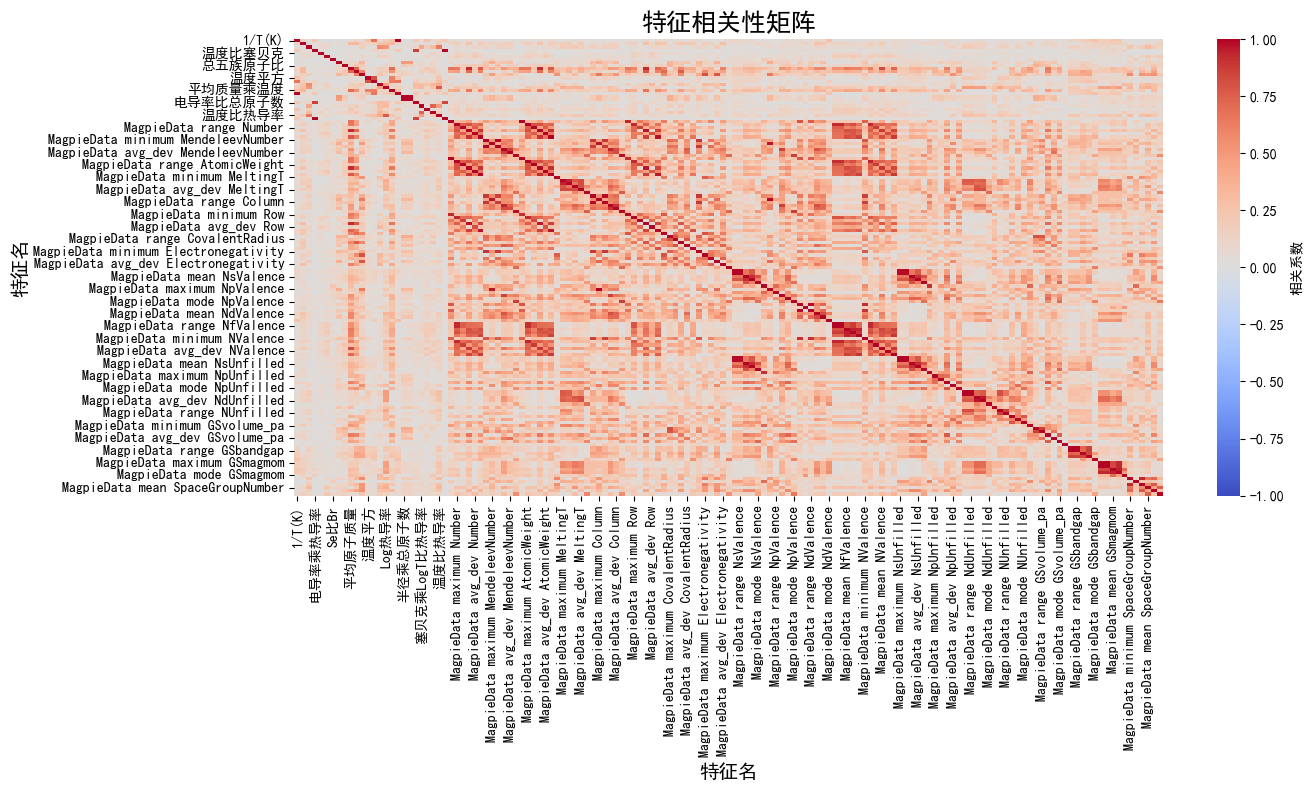

In [12]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

# 设置中文显示字体（优先使用常见中文字体）
def set_chinese_font():
    font_names = ["SimHei", "Microsoft YaHei", "STHeiti", "Arial Unicode MS"]
    found = False
    for font_name in font_names:
        try:
            plt.rcParams['font.sans-serif'] = [font_name]
            plt.rcParams['axes.unicode_minus'] = False
            # 检查字体是否可用
            if any(font_name in f.name for f in font_manager.fontManager.ttflist):
                found = True
                break
        except Exception:
            continue
    if not found:
        print("⚠️ 未能找到可用的中文字体，中文可能无法正常显示。")

set_chinese_font()

# 读取当前目录下data文件夹里的character.csv
df = pd.read_csv('data/character.csv')

# 找到ZT所在列
if 'ZT' not in df.columns:
    raise ValueError("列 'ZT' 不存在于character.csv, 请检查数据！")
zt_idx = df.columns.get_loc('ZT')
# ZT之后(不包含ZT)的所有特征列
feature_cols = df.columns[(zt_idx + 1):]
X = df[feature_cols]

# 特征相关性分析
corr_matrix = X.corr().abs()
# 仅保留上三角
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_pairs = [
    (col1, col2, upper.loc[col1, col2]) 
    for col1 in upper.columns for col2 in upper.columns 
    if (col1 != col2) and (pd.notnull(upper.loc[col1, col2])) and (upper.loc[col1, col2] > 0.85)
]

# 输出相关性大于0.85的特征对
print("特征相关性大于0.85的特征对：")
for col1, col2, corr in high_corr_pairs:
    print(f"{col1} <--> {col2} : {corr:.3f}")

# 画热力图并设置中文相关属性
plt.figure(figsize=(14, 8))
sns.heatmap(
    corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, 
    cbar_kws={'label': '相关系数'}
)
plt.title('特征相关性矩阵', fontsize=18)
plt.xlabel("特征名", fontsize=14)
plt.ylabel("特征名", fontsize=14)
plt.tight_layout()
plt.show()


读取当前目录下的data文件夹的character.csv文件，ZT列不包括ZT列后的所有列都是特征注意第一列是列名，目标为S( μV/K)，建立机器学习模型。将数据打乱后做归一化注意数据泄露，将数据分为测试集和训练集2、8分，对训练集数据进行5折交叉验证，输出每一次的结果，采用XGBoosting、XGBoost、SVR、KNN、Lasso、 Extra Trees Regressor
模型，并优化超参数，测试集数据不参与验证和模型优化，优化完最优参数后，用测试集数据测试，画出训练集和测试集的真实和预测值的图画在一张上，输出R2和MAE。再图中标注模型名称，图中用纯英文

# 塞贝克系数


XGBoosting 5-fold cross-validation:


Exception in thread Thread-40039 (_readerthread):
Traceback (most recent call last):
  File "d:\anconda3\envs\wzy\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "d:\anconda3\envs\wzy\lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "d:\anconda3\envs\wzy\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "d:\anconda3\envs\wzy\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "d:\anconda3\envs\wzy\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002083 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13453
[LightGBM] [Info] Number of data points in the train set: 2661, number of used features: 129
[LightGBM] [Info] Start training from score 75.363705
Best params: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 63}
Param set 1: Mean R2=0.5982, Std R2=0.0200
Param set 2: Mean R2=0.6784, Std R2=0.0259
Param set 3: Mean R2=0.7164, Std R2=0.0271
Param set 4: Mean R2=0.7527, Std R2=0.0285
Param set 5: Mean R2=0.8224, Std R2=0.0278
Param set 6: Mean R2=0.8542, Std R2=0.0283
Param set 7: Mean R2=0.8880, Std R2=0.0257
Param set 8: Mean R2=0.9130, Std R2=0.0215
Param set 9: Mean R2=0.9219, Std R2=0.0208
Param set 10: Mean R2=0.9092, Std R2=0.0223
Param set 11: Mean R2=0.9235, Std R2=0.0199
Param set 12: Mean R2=0.9267, Std R2=0.0194
Train     R2: 0.9860, MAE: 10.6174
Valid     R2: 0.9547, MAE: 

d:\anconda3\envs\wzy\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\anconda3\envs\wzy\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\anconda3\envs\wzy\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Param set 1: Mean R2=0.4139, Std R2=0.0138
Param set 2: Mean R2=0.5453, Std R2=0.0145
Param set 3: Mean R2=0.6218, Std R2=0.0242
Param set 4: Mean R2=0.7664, Std R2=0.0272
Param set 5: Mean R2=0.7117, Std R2=0.0213
Param set 6: Mean R2=0.8551, Std R2=0.0217
Param set 7: Mean R2=0.8130, Std R2=0.0261
Param set 8: Mean R2=0.8742, Std R2=0.0199
Param set 9: Mean R2=0.8989, Std R2=0.0251
Param set 10: Mean R2=0.9205, Std R2=0.0197
Param set 11: Mean R2=0.9242, Std R2=0.0194
Param set 12: Mean R2=0.9304, Std R2=0.0184
Train     R2: 0.9925, MAE: 9.9982
Valid     R2: 0.9539, MAE: 23.3162
Test      R2: 0.9543, MAE: 22.8244

SVR 5-fold cross-validation:
Best params: {'C': 10, 'epsilon': 0.1, 'kernel': 'linear'}
Param set 1: Mean R2=0.0016, Std R2=0.0107
Param set 2: Mean R2=0.2780, Std R2=0.0261
Param set 3: Mean R2=0.0016, Std R2=0.0107
Param set 4: Mean R2=0.2780, Std R2=0.0260
Param set 5: Mean R2=0.1164, Std R2=0.0046


d:\anconda3\envs\wzy\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.138e+07, tolerance: 1.181e+04
  model = cd_fast.enet_coordinate_descent(


Best params: {'alpha': 0.001}
Param set 1: Mean R2=0.5875, Std R2=0.0368
Param set 2: Mean R2=0.5873, Std R2=0.0366
Param set 3: Mean R2=0.5808, Std R2=0.0371
Param set 4: Mean R2=0.5173, Std R2=0.0385
Train     R2: 0.6297, MAE: 95.1906
Valid     R2: 0.6368, MAE: 98.1988
Test      R2: 0.6202, MAE: 98.7479

ExtraTrees 5-fold cross-validation:
Best params: {'max_depth': None, 'n_estimators': 200}
Param set 1: Mean R2=0.5979, Std R2=0.0211
Param set 2: Mean R2=0.6023, Std R2=0.0224
Param set 3: Mean R2=0.5993, Std R2=0.0239
Param set 4: Mean R2=0.8689, Std R2=0.0184
Param set 5: Mean R2=0.8699, Std R2=0.0189
Param set 6: Mean R2=0.8658, Std R2=0.0201
Param set 7: Mean R2=0.9197, Std R2=0.0217
Param set 8: Mean R2=0.9189, Std R2=0.0225
Param set 9: Mean R2=0.9199, Std R2=0.0218
Train     R2: 0.9987, MAE: 0.7589
Valid     R2: 0.9532, MAE: 18.6028
Test      R2: 0.9634, MAE: 18.2856


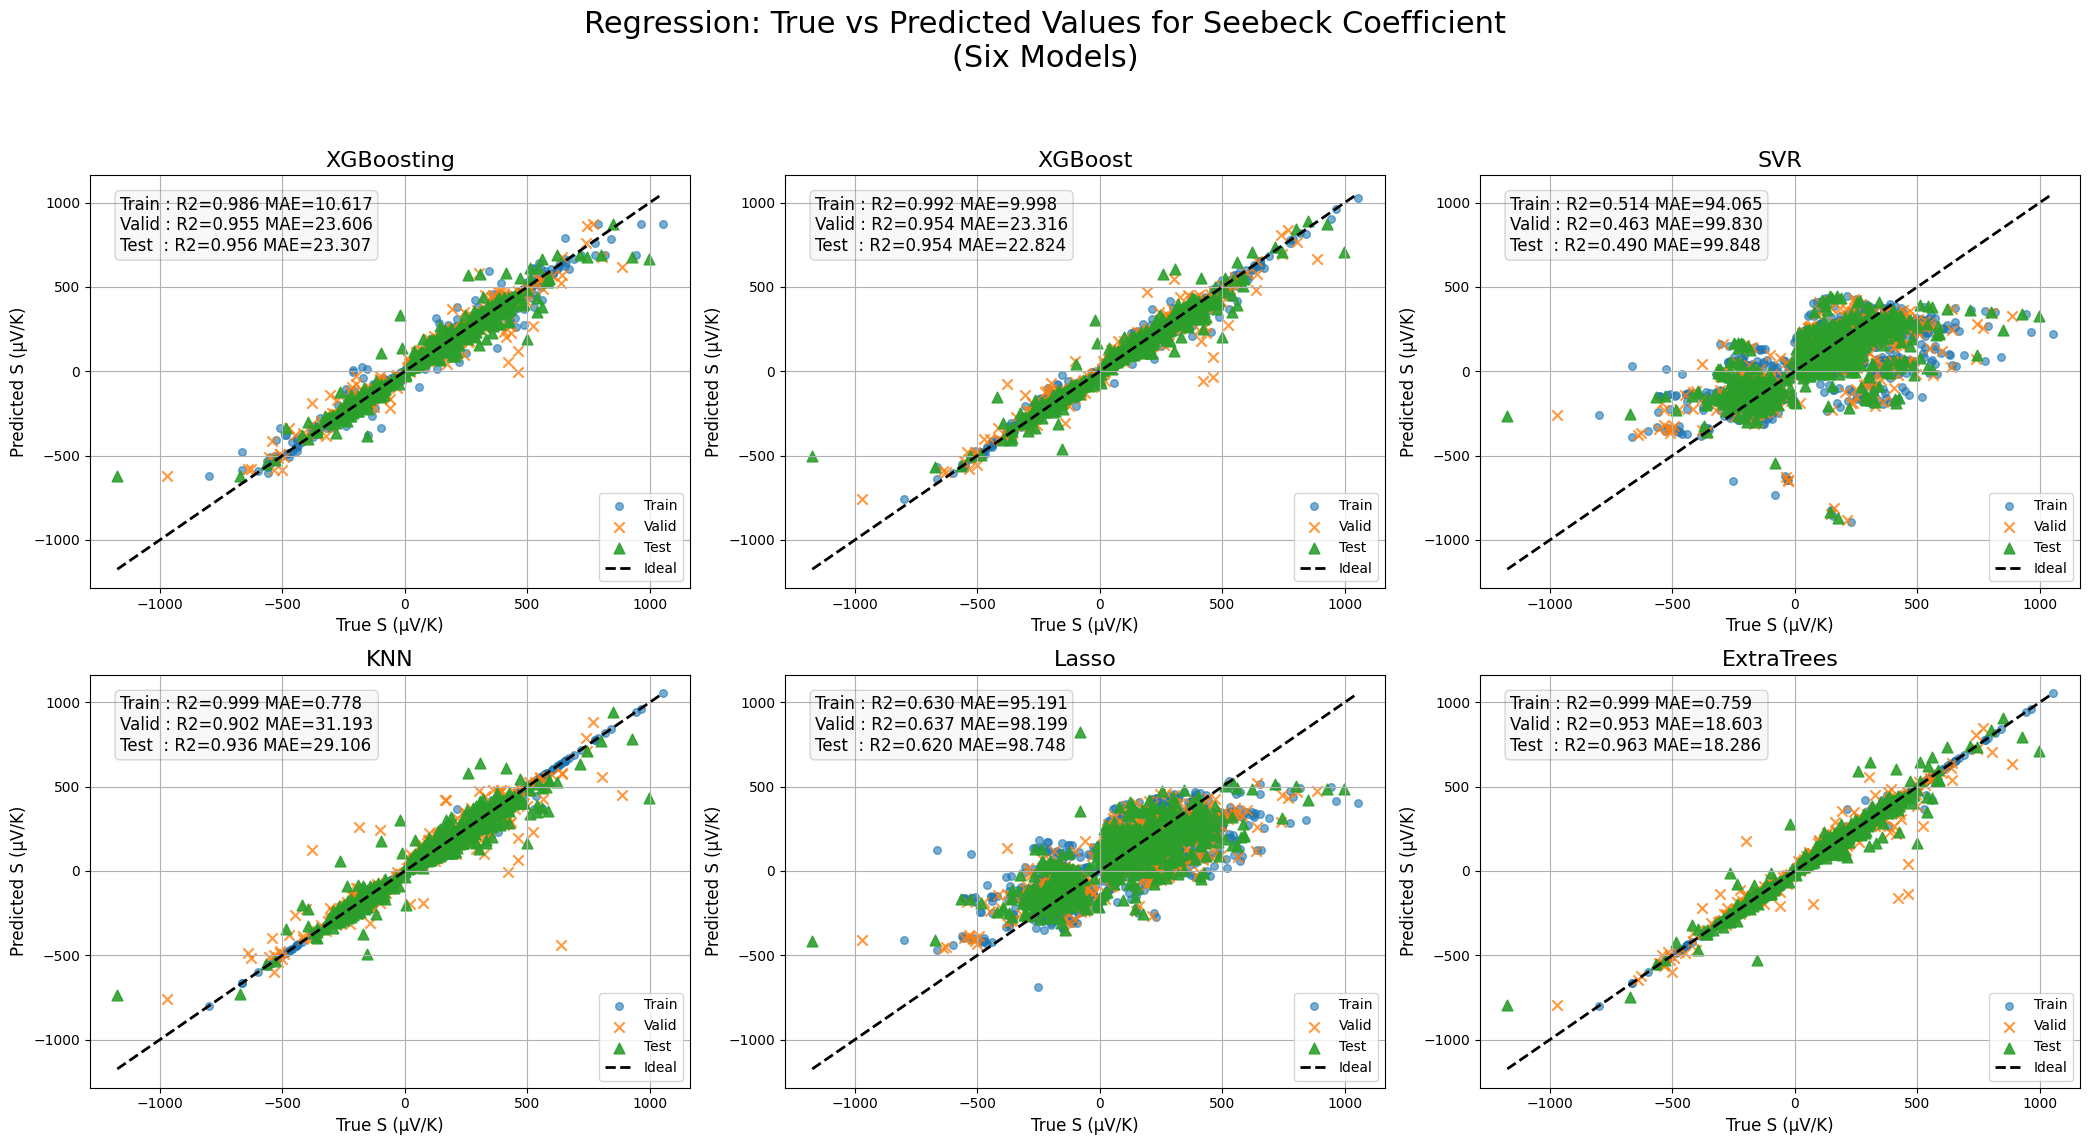


Train/Valid/Test set R2 and MAE summary:
XGBoosting      | Train R2: 0.9860, MAE: 10.6174 | Valid R2: 0.9547, MAE: 23.6062 | Test R2: 0.9560, MAE: 23.3073
XGBoost         | Train R2: 0.9925, MAE: 9.9982 | Valid R2: 0.9539, MAE: 23.3162 | Test R2: 0.9543, MAE: 22.8244
SVR             | Train R2: 0.5137, MAE: 94.0650 | Valid R2: 0.4627, MAE: 99.8301 | Test R2: 0.4900, MAE: 99.8481
KNN             | Train R2: 0.9986, MAE: 0.7783 | Valid R2: 0.9022, MAE: 31.1926 | Test R2: 0.9360, MAE: 29.1064
Lasso           | Train R2: 0.6297, MAE: 95.1906 | Valid R2: 0.6368, MAE: 98.1988 | Test R2: 0.6202, MAE: 98.7479
ExtraTrees      | Train R2: 0.9987, MAE: 0.7589 | Valid R2: 0.9532, MAE: 18.6028 | Test R2: 0.9634, MAE: 18.2856


In [7]:
# 设置随机种子42在最前方，保证实验可复现
import numpy as np
import random
np.random.seed(42)
random.seed(42)

import pandas as pd
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('data/character.csv')
if 'ZT' not in df.columns:
    raise ValueError("ZT column not found!")
zt_idx = df.columns.get_loc('ZT')
feature_cols = df.columns[(zt_idx + 1):]
target_col = 'S( μV/K)'  # 目标列名，根据实际列名修改
if target_col not in df.columns:
    # 可能没有空格或中文括号，自动查找目标
    target_candidates = [c for c in df.columns if 'S' in c and 'V' in c and '/' in c]
    if target_candidates:
        target_col = target_candidates[0]
    else:
        raise ValueError('Target column for Seebeck Coefficient S (μV/K) not found!')

# 提取特征与目标
X = df[feature_cols].copy()
y = df[target_col].copy()

# 按6:2:2比例划分训练集、验证集和测试集
# 首先拆出训练集（60%），剩余为valid+test（40%）
X_train, X_extra, y_train, y_extra = train_test_split(
    X, y, test_size=0.4, random_state=42, shuffle=True
)
# 再将剩下的40%一半一半分为验证集和测试集（各20%）
X_valid, X_test, y_valid, y_test = train_test_split(
    X_extra, y_extra, test_size=0.5, random_state=42, shuffle=True
)

# 归一化（仅用训练集fit，避免数据泄露）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# 5折交叉验证
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "XGBoosting": lgb.LGBMRegressor(),
    "XGBoost": XGBRegressor(verbosity=0, objective='reg:squarederror'),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "Lasso": Lasso(max_iter=10000),
    "ExtraTrees": ExtraTreesRegressor(random_state=42),
}
param_grids = {
    "XGBoosting": {
        'num_leaves': [15, 31, 63], 'learning_rate': [0.01, 0.1], 'n_estimators': [100, 200]
    },
    "XGBoost": {
        'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1], 'n_estimators': [100, 200]
    },
    "SVR": {
        'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'epsilon': [0.01, 0.1]
    },
    "KNN": {
        'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']
    },
    "Lasso": {
        'alpha': [0.001, 0.01, 0.1, 1]
    },
    "ExtraTrees": {
        'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]
    }
}
best_results = {}

# 创建单独的六张子图
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    print(f'\n{name} 5-fold cross-validation:')

    # 超参数优化
    grid = GridSearchCV(model, param_grids[name], cv=kf, scoring='r2', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    print(f"Best params: {grid.best_params_}")
    cv_results = grid.cv_results_
    for i, (mean_r2, std_r2) in enumerate(zip(cv_results['mean_test_score'], cv_results['std_test_score'])):
        print(f"Param set {i+1}: Mean R2={mean_r2:.4f}, Std R2={std_r2:.4f}")

    # 预测及评估: 训练、验证、测试集
    y_train_pred = grid.predict(X_train_scaled)
    y_valid_pred = grid.predict(X_valid_scaled)
    y_test_pred = grid.predict(X_test_scaled)
    r2_train = r2_score(y_train, y_train_pred)
    r2_valid = r2_score(y_valid, y_valid_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_valid = mean_absolute_error(y_valid, y_valid_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    print(f"Train     R2: {r2_train:.4f}, MAE: {mae_train:.4f}")
    print(f"Valid     R2: {r2_valid:.4f}, MAE: {mae_valid:.4f}")
    print(f"Test      R2: {r2_test:.4f}, MAE: {mae_test:.4f}")

    best_results[name] = {
        "model": grid.best_estimator_,
        "train_true": y_train,
        "train_pred": y_train_pred,
        "valid_true": y_valid,
        "valid_pred": y_valid_pred,
        "test_true": y_test,
        "test_pred": y_test_pred,
        "r2_train": r2_train,
        "r2_valid": r2_valid,
        "r2_test": r2_test,
        "mae_train": mae_train,
        "mae_valid": mae_valid,
        "mae_test": mae_test
    }

    # 为每个模型作图，显示train/valid/test点，标注R2/MAE
    ax = axes[idx]
    ax.scatter(y_train, y_train_pred, c='tab:blue', label='Train', alpha=0.60, s=30)
    ax.scatter(y_valid, y_valid_pred, c='tab:orange', label='Valid', marker='x', alpha=0.80, s=55)
    ax.scatter(y_test, y_test_pred, c='tab:green', label='Test', marker='^', alpha=0.90, s=60)
    all_y = np.concatenate([y_train, y_valid, y_test])
    ax.plot(
        [all_y.min(), all_y.max()],
        [all_y.min(), all_y.max()],
        'k--', lw=2, label='Ideal'
    )

    # 标注所有集的R2和MAE
    textstr = (
        f"Train : R2={r2_train:.3f} MAE={mae_train:.3f}\n"
        f"Valid : R2={r2_valid:.3f} MAE={mae_valid:.3f}\n"
        f"Test  : R2={r2_test:.3f} MAE={mae_test:.3f}"
    )
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.15, facecolor='lightgrey'))

    ax.set_title(f"{name}", fontsize=16)
    ax.set_xlabel("True S (μV/K)", fontsize=12)
    ax.set_ylabel("Predicted S (μV/K)", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True)

# 移除多余的空白子图(如果模型数小于6)
for i in range(len(models), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle("Regression: True vs Predicted Values for Seebeck Coefficient\n(Six Models)", fontsize=22)
fig.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()

# 输出各模型在Train/Valid/Test集的R2和MAE
print("\nTrain/Valid/Test set R2 and MAE summary:")
for name, res in best_results.items():
    print(f"{name:15s} | Train R2: {res['r2_train']:.4f}, MAE: {res['mae_train']:.4f} | "
          f"Valid R2: {res['r2_valid']:.4f}, MAE: {res['mae_valid']:.4f} | "
          f"Test R2: {res['r2_test']:.4f}, MAE: {res['mae_test']:.4f}")

### Key15 character

--- 0. 数据加载与目标定义 ---
数据总样本数: 4436
识别到的 Matminer/手动特征数量: 128
回归目标: ['S_amp_linear', 'sigma_log', 'k_linear']

--- 1. 共线性特征过滤 (ρ > 0.8) ---
删除高共线性特征数量: 66
皮尔逊过滤后保留的 Matminer/手动特征数量: 62

--- 2. 独立目标 Extra Trees 特征递减搜索 (含 k 关键特征保留逻辑) ---

--- 🚀 目标: S (S_amp_linear) 特征筛选 ---
N_Matminer: 62 | R2: 0.9519 | MAE: 18.0494
N_Matminer: 61 | R2: 0.9520 | MAE: 18.0111
N_Matminer: 60 | R2: 0.9509 | MAE: 17.9992
N_Matminer: 59 | R2: 0.9519 | MAE: 18.0214
N_Matminer: 58 | R2: 0.9523 | MAE: 17.9574
N_Matminer: 57 | R2: 0.9514 | MAE: 17.9914
N_Matminer: 56 | R2: 0.9519 | MAE: 17.9898
N_Matminer: 55 | R2: 0.9517 | MAE: 17.9831
N_Matminer: 54 | R2: 0.9513 | MAE: 18.0771
N_Matminer: 53 | R2: 0.9523 | MAE: 17.9865
N_Matminer: 52 | R2: 0.9517 | MAE: 18.0048
N_Matminer: 51 | R2: 0.9499 | MAE: 18.1093
N_Matminer: 50 | R2: 0.9519 | MAE: 17.9463
N_Matminer: 49 | R2: 0.9528 | MAE: 17.9327
N_Matminer: 48 | R2: 0.9519 | MAE: 18.0244
N_Matminer: 47 | R2: 0.9516 | MAE: 18.0275
N_Matminer: 46 | R2: 0.9518 | MAE: 18.025

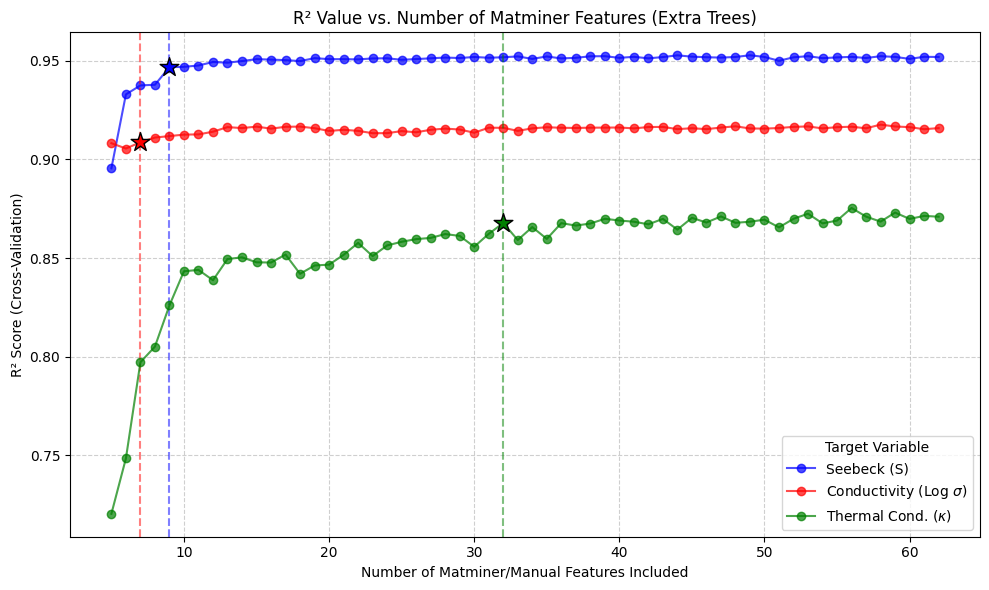

In [2]:
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor, ExtraTreesClassifier
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
import sys
import matplotlib.pyplot as plt
import os

# --- 🎯 全局配置与辅助变量 ---
LOG_TARGETS_EPS = 1e-10
RANDOM_STATE = 42
N_CV_SPLITS = 5
OUTPUT_DIR = os.path.join(os.getcwd(), 'output_extra_trees')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(os.getcwd(), 'data'), exist_ok=True)
os.makedirs(os.path.join(os.getcwd(), 'picture'), exist_ok=True) # 确保 picture 文件夹存在

# ----------------------------------------------------------------------
# 1. 数据加载与目标变量定义 (保持不变)
# ----------------------------------------------------------------------
def load_data_and_define_targets():
    """
    从 './data/character.csv' 文件加载数据，并根据 ZT 列的位置确定特征。
    假设 S( μV/K), Log(σ(S/m)), k(W/Km), T(K), ZT 包含在 character.csv 中。
    """
    print("--- 0. 数据加载与目标定义 ---")

    FILE_PATH = os.path.join('data', 'character.csv')

    if not os.path.exists(FILE_PATH):
        print(f"致命错误: 未找到文件路径: {FILE_PATH}")
        sys.exit(1)

    try:
        df = pd.read_csv(FILE_PATH)

        # 确保关键列存在 (使用用户提供的精确列名)
        required_cols = ['S( μV/K)', 'Log(σ(S/m))', 'k(W/Km)', 'T(K)', 'ZT']
        for col in required_cols:
            if col not in df.columns:
                print(f"错误: 文件 {FILE_PATH} 缺少必需的目标列 '{col}'。")
                sys.exit(1)

    except Exception as e:
        print(f"文件加载或解析失败: {e}")
        sys.exit(1)

    # --- 确定 Matminer 特征列 ---
    target_and_metadata_cols = ['wt%', 'Formula', 'S( μV/K)', 'σ(S/m)', 'Log(σ(S/m))', 'k(W/Km)', 'PF(W/mK2)', 'ZT']
    
    # 找到 T(K) 的索引
    t_col_name = 'T(K)'
    if t_col_name in df.columns:
        t_index = df.columns.get_loc(t_col_name)
        # 假设所有 T(K) 之后的非目标列都是 Matminer/手动特征
        matminer_cols = [col for col in df.columns[t_index + 1:].tolist() if col not in target_and_metadata_cols]
    else:
        matminer_cols = []

    if not matminer_cols:
        print("警告: 在 T(K) 列之后未找到任何 Matminer/手动构建特征。请检查文件结构。")

    # --- 目标变量定义 (S/k 线性, log_sigma 直接采用列名) ---
    df_raw = df[['S( μV/K)', 'Log(σ(S/m))', 'k(W/Km)', 'T(K)']].copy()

    # 定义模型目标变量
    df_raw['S_sign'] = np.sign(df_raw['S( μV/K)']).astype(int)
    df_raw['S_amp_linear'] = df_raw['S( μV/K)']
    df_raw['sigma_log'] = df_raw['Log(σ(S/m))']
    df_raw['k_linear'] = df_raw['k(W/Km)']

    target_cols = ['S_sign', 'S_amp_linear', 'sigma_log', 'k_linear']

    # --- 整合数据 ---
    # 合并 Matminer/手动特征和目标变量
    df_combined = pd.concat([df_raw, df[matminer_cols]], axis=1)

    # 添加温度特征 (作为模型的基础输入)
    df_combined['T_inv'] = 1.0 / df_combined['T(K)']
    df_combined['T_log'] = np.log(df_combined['T(K)'])
    
    # 清理无穷值和NaN
    df_combined = df_combined.replace([np.inf, -np.inf], np.nan).dropna(subset=target_cols[1:])

    print(f"数据总样本数: {len(df_combined)}")
    print(f"识别到的 Matminer/手动特征数量: {len(matminer_cols)}")
    print(f"回归目标: {target_cols[1:]}")

    return df_combined, matminer_cols, target_cols

# ----------------------------------------------------------------------
# 2. 共线性特征过滤 (皮尔逊相关性 > 0.8) (保持不变)
# ----------------------------------------------------------------------
def filter_features_by_correlation(df_combined, matminer_cols, target_cols, threshold=0.8):
    """ 基于皮尔逊相关性对特征进行过滤，解决共线性问题。 """
    print(f"\n--- 1. 共线性特征过滤 (ρ > {threshold}) ---")

    if not matminer_cols:
        return []

    regression_targets = [col for col in target_cols if col != 'S_sign']
    X = df_combined[matminer_cols].copy()
    X = X.fillna(X.mean())

    # a) 计算特征与回归目标的平均绝对相关性 (用于优先级排序)
    corr_to_targets = pd.DataFrame()
    for t_col in regression_targets:
        corr_to_targets[t_col] = X.corrwith(df_combined[t_col]).abs()
    avg_corr_scores = corr_to_targets.mean(axis=1).sort_values(ascending=False)

    # b) 计算特征间的相关矩阵
    corr_matrix_features = X.corr().abs()

    features_to_drop = set()

    for i in range(len(matminer_cols)):
        feat1 = matminer_cols[i]
        if feat1 in features_to_drop: continue

        for j in range(i + 1, len(matminer_cols)):
            feat2 = matminer_cols[j]
            if feat2 in features_to_drop: continue

            if corr_matrix_features.loc[feat1, feat2] >= threshold:
                # 保留与目标平均相关性高的特征
                corr1 = avg_corr_scores.loc[feat1]
                corr2 = avg_corr_scores.loc[feat2]

                if corr1 < corr2:
                    features_to_drop.add(feat1)
                else:
                    features_to_drop.add(feat2)

    final_matminer_cols = [col for col in matminer_cols if col not in features_to_drop]
    print(f"删除高共线性特征数量: {len(matminer_cols) - len(final_matminer_cols)}")
    print(f"皮尔逊过滤后保留的 Matminer/手动特征数量: {len(final_matminer_cols)}")

    return final_matminer_cols


# ----------------------------------------------------------------------
# 3. Extra Trees 模型评估函数 (针对单一目标) (保持不变)
# ----------------------------------------------------------------------
def evaluate_single_target_cv(X, Y_target, n_splits=N_CV_SPLITS, random_state=RANDOM_STATE):
    """ 使用 K-Fold CV 评估单一回归目标的 R^2 和 MAE """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    r2_list = []
    mae_list = []

    X_np = X.values
    Y_np = Y_target.values

    scaler = StandardScaler()

    for train_index, test_index in kf.split(X_np):
        X_train, X_test = X_np[train_index], X_np[test_index]
        Y_train, Y_test = Y_np[train_index], Y_np[test_index]

        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        # --- 回归器 ---
        reg = ExtraTreesRegressor(n_estimators=100, random_state=random_state, n_jobs=-1)
        reg.fit(X_train_s, Y_train)
        Y_pred = reg.predict(X_test_s)

        r2_list.append(r2_score(Y_test, Y_pred))
        mae_list.append(mean_absolute_error(Y_test, Y_pred))

    return np.mean(r2_list), np.mean(mae_list)


# ----------------------------------------------------------------------
# 4. 独立目标特征递减搜索主逻辑 (已修改，增加 k 模型关键特征保留逻辑)
# ----------------------------------------------------------------------
def run_independent_backward_selection(df_combined, target_cols, initial_matminer_cols):
    """ 分别针对 S, sigma_log, k 三个目标进行特征递减搜索。 """
    print("\n--- 2. 独立目标 Extra Trees 特征递减搜索 (含 k 关键特征保留逻辑) ---")

    if not initial_matminer_cols:
        return {}

    # 包含温度的特征 (作为模型的通用输入)
    T_features = ['T(K)', 'T_inv', 'T_log']

    # 定义要筛选的回归目标及其对应的内部列名
    target_map = {
        'S': 'S_amp_linear',
        'sigma': 'sigma_log',
        'k': 'k_linear'
    }

    best_features_dict = {}

    # 初始化关键特征集合 (k 模型特有)
    CRITICAL_R2_DROP_THRESHOLD = 0.05
    critical_k_features = set()

    for target_name, target_col in target_map.items():
        print(f"\n--- 🚀 目标: {target_name} ({target_col}) 特征筛选 ---")

        # 1. 计算特征与当前目标的绝对相关性 (用于排序)
        X_matminer_full = df_combined[initial_matminer_cols].fillna(df_combined[initial_matminer_cols].mean())

        # 升序：相关性低 -> 高 (这是我们要尝试删除的顺序)
        corr_scores = X_matminer_full.corrwith(df_combined[target_col]).abs().sort_values(ascending=True)

        # 2. 递减搜索初始化
        Y = df_combined[target_col]
        
        # 用于评估的特征列表 (Matminer 部分)
        current_matminer_features = X_matminer_full.columns.tolist() 
        
        # 按照相关性升序的特征列表 (待删除顺序)
        sorted_features_to_drop = corr_scores.index.tolist()
        features_to_drop_idx = 0
        
        results_list_with_feats = []
        previous_r2 = -np.inf # 用于比较 R² 下降

        # 3. 递减搜索循环
        while len(current_matminer_features) >= 5:
            # --- 3.1. 评估当前子集 ---
            X_eval_cols = current_matminer_features + T_features
            X_eval = df_combined[X_eval_cols].fillna(df_combined[X_eval_cols].mean())
            r2, mae = evaluate_single_target_cv(X_eval, Y)
            
            # 记录历史数据
            results_list_with_feats.append({
                'count': len(current_matminer_features),
                'R2': r2,
                'MAE': mae,
                'features': current_matminer_features.copy()
            })
            print(f"N_Matminer: {len(current_matminer_features)} | R2: {r2:.4f} | MAE: {mae:.4f}")

            if len(current_matminer_features) <= 5:
                break # 达到最小特征数，退出循环

            # --- 3.2. 决定下一轮要移除的特征 ---
            feature_to_remove = None
            feature_found = False

            # 循环寻找下一个可以移除的特征
            while features_to_drop_idx < len(sorted_features_to_drop):
                next_feature_to_try = sorted_features_to_drop[features_to_drop_idx]
                
                # 检查是否是 k 模型必须保留的关键特征
                if target_name == 'k' and next_feature_to_try in critical_k_features:
                    # 如果是关键特征，则跳过这个特征，尝试下一个
                    features_to_drop_idx += 1
                    continue
                else:
                    feature_to_remove = next_feature_to_try
                    feature_found = True
                    break

            if not feature_found:
                break # 没有更多特征可以移除了 (只剩下关键特征)

            # --- 3.3. 检查 k 模型 R² 下降阈值 (仅针对 k) ---
            if target_name == 'k':
                # 模拟移除特征后的性能
                temp_matminer_features = [f for f in current_matminer_features if f != feature_to_remove]
                X_next_eval_cols = temp_matminer_features + T_features
                X_next_eval = df_combined[X_next_eval_cols].fillna(df_combined[X_next_eval_cols].mean())
                next_r2, _ = evaluate_single_target_cv(X_next_eval, Y)
                
                r2_drop = r2 - next_r2

                if r2_drop >= CRITICAL_R2_DROP_THRESHOLD:
                    # 发现关键特征，将其加入保留列表，并跳过本轮移除
                    critical_k_features.add(feature_to_remove)
                    features_to_drop_idx += 1 # 继续检查下一个特征是否可以移除
                    print(f"   [保留] {feature_to_remove} (R² 下降 {r2_drop:.4f} >= {CRITICAL_R2_DROP_THRESHOLD})")
                    continue # 重新进入 while 循环的顶部，评估新的 current_matminer_features (未移除)

            # --- 3.4. 移除特征 (满足所有条件) ---
            current_matminer_features.remove(feature_to_remove)
            features_to_drop_idx += 1 # 更新待移除特征的索引

        # 4. **新逻辑：选择最简约的最优子集**
        
        history_df = pd.DataFrame(results_list_with_feats)

        # 找到 R² 最高的行
        max_r2_row = history_df.loc[history_df['R2'].idxmax()]
        
        # 找到满足 R² 阈值 (99%) 的最简约子集
        R2_TOLERANCE = 0.99
        r2_threshold = max_r2_row['R2'] * R2_TOLERANCE
        
        good_results = history_df[history_df['R2'] >= r2_threshold]
        
        if good_results.empty:
            final_best_row = max_r2_row
        else:
            # 选择 'count' 最小的行（最简约）
            final_best_row = good_results.loc[good_results['count'].idxmin()]
            
        final_best_r2 = final_best_row['R2']
        final_best_mae = final_best_row['MAE']
        final_best_feats = final_best_row['features']

        print(f"--- ✅ {target_name} 最优特征数量 (简约原则): {len(final_best_feats)} (R2: {final_best_r2:.4f}) ---")
        if target_name == 'k':
            print(f"--- ⚠️ k 模型保留的关键特征数量: {len(critical_k_features)} ---")
        
        best_features_dict[target_name] = {
            'features': final_best_feats, 
            'R2': final_best_r2, 
            'MAE': final_best_mae, 
            'history': history_df[['count', 'R2', 'MAE']] # 只保留作图所需数据
        }

    return best_features_dict


# ----------------------------------------------------------------------
# 5. 结果可视化和保存 (独立文件 + 绘图) (保持不变)
# ----------------------------------------------------------------------
def save_and_plot_results(best_features_dict):
    print("\n--- 3. 结果保存与可视化 ---")
    data_dir = os.path.join(os.getcwd(), 'data')
    picture_dir = os.path.join(os.getcwd(), 'picture')

    summary_data = []

    # --- 5.1 保存最优特征到独立文件 ---
    for target_name, data in best_features_dict.items():
        best_features = data['features']
        best_r2 = data['R2']
        best_mae = data['MAE']

        output_path = os.path.join(data_dir, f'min_character_{target_name}.csv')
        df_best = pd.DataFrame({
            'Feature_Name': best_features,
            'Best_R2': [best_r2] * len(best_features),
            'Best_MAE': [best_mae] * len(best_features)
        })
        df_best.to_csv(output_path, index=False)
        print(f"✅ {target_name} 最优特征 ({len(best_features)} 个) 已保存到: {output_path}")

        summary_data.append({
            'Target': target_name,
            'N_Features': len(best_features),
            'Best R2': f'{best_r2:.4f}',
            'Best MAE': f'{best_mae:.4f}'
        })

    # 打印总结表格
    summary_df = pd.DataFrame(summary_data)
    print("\n--- 独立特征筛选总结 ---")
    print(summary_df.to_markdown(index=False))

    # --- 5.2 R^2 随特征数量变化作图 ---
    plt.figure(figsize=(10, 6))

    colors = {'S': 'blue', 'sigma': 'red', 'k': 'green'}
    target_labels = {'S': 'Seebeck (S)', 'sigma': 'Conductivity (Log $\\sigma$)', 'k': 'Thermal Cond. ($\\kappa$)'}

    for target_name, data in best_features_dict.items():
        history_df = data['history'].sort_values('count', ascending=True) # 确保按数量升序
        best_r2 = data['R2']
        n_best_feats = len(data['features'])

        # 绘制 R^2 曲线
        plt.plot(history_df['count'], history_df['R2'],
                 marker='o', linestyle='-',
                 color=colors[target_name],
                 label=target_labels[target_name],
                 alpha=0.7)

        # 标出最优特征数量点
        plt.axvline(x=n_best_feats, color=colors[target_name], linestyle='--', alpha=0.5)
        plt.scatter(n_best_feats, best_r2,
                    marker='*', s=200,
                    color=colors[target_name],
                    edgecolor='black',
                    zorder=5)

    plt.title('R² Value vs. Number of Matminer Features (Extra Trees)')
    plt.xlabel('Number of Matminer/Manual Features Included')
    plt.ylabel('R² Score (Cross-Validation)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Target Variable")
    plt.tight_layout()

    # 保存图片
    plot_path = os.path.join(picture_dir, 'diff_character.png')
    plt.savefig(plot_path, dpi=300)
    print(f"\n🖼️ R² 变化图已保存到: {plot_path}")


# ----------------------------------------------------------------------
# 6. 主执行块 (保持不变)
# ----------------------------------------------------------------------
if __name__ == '__main__':
    # 忽略 Matplotlib 的运行时警告
    warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
    
    # 1. 数据准备
    df_combined, matminer_cols, target_cols = load_data_and_define_targets()

    # 2. 共线性过滤
    initial_matminer_cols = filter_features_by_correlation(df_combined, matminer_cols, target_cols)

    # 3. 独立目标特征递减搜索 (使用新的最优选择逻辑)
    best_features_dict = run_independent_backward_selection(df_combined, target_cols, initial_matminer_cols)

    # 4. 保存、展示结果和作图
    if best_features_dict:
        save_and_plot_results(best_features_dict)
    else:
        print("\n未进行递减搜索或结果为空，请检查数据文件和目标变量。")

# Log电导率

Train: 2661, Valid: 887, Test: 888 (Total: 4436)

Model: XGBoosting
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002335 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13451
[LightGBM] [Info] Number of data points in the train set: 2661, number of used features: 129
[LightGBM] [Info] Start training from score 4.320812
Best Params: {'learning_rate': 0.1, 'n_estimators': 150}
Train R2: 0.9640 | Valid R2: 0.9240 | Test R2: 0.8934
Train MAE: 0.1021 | Valid MAE: 0.1643 | Test MAE: 0.1653

Model: XGBoost


d:\anconda3\envs\wzy\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\anconda3\envs\wzy\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\anconda3\envs\wzy\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Best Params: {'learning_rate': 0.1, 'n_estimators': 150}
Train R2: 0.9675 | Valid R2: 0.9313 | Test R2: 0.9020
Train MAE: 0.1084 | Valid MAE: 0.1688 | Test MAE: 0.1664

Model: SVR
Best Params: {'C': 10, 'gamma': 'auto'}
Train R2: 0.8301 | Valid R2: 0.8347 | Test R2: 0.8364
Train MAE: 0.2215 | Valid MAE: 0.2412 | Test MAE: 0.2300

Model: KNN
Best Params: {'n_neighbors': 3}
Train R2: 0.9290 | Valid R2: 0.8936 | Test R2: 0.8331
Train MAE: 0.1355 | Valid MAE: 0.2011 | Test MAE: 0.2082

Model: Lasso
Best Params: {'alpha': 0.01}
Train R2: 0.4927 | Valid R2: 0.4746 | Test R2: 0.4829
Train MAE: 0.5144 | Valid MAE: 0.5270 | Test MAE: 0.4917

Model: ExtraTrees
Best Params: {'n_estimators': 150}
Train R2: 0.9922 | Valid R2: 0.9504 | Test R2: 0.8980
Train MAE: 0.0065 | Valid MAE: 0.0997 | Test MAE: 0.1083


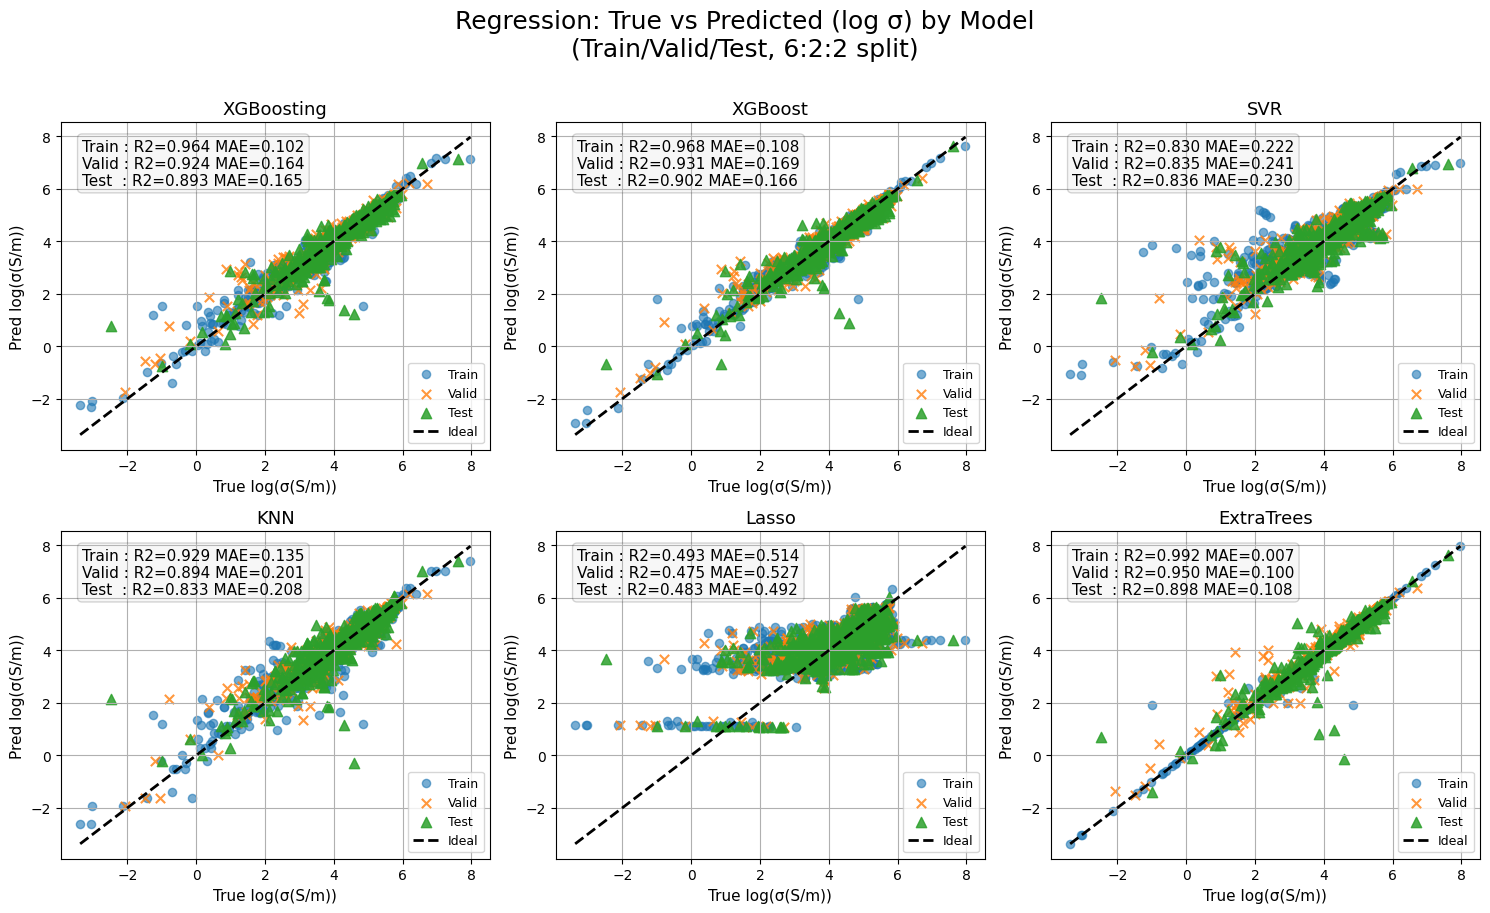


Train/Valid/Test set R2 and MAE summary (log σ):
XGBoosting      | Train R2: 0.9640, MAE: 0.1021 | Valid R2: 0.9240, MAE: 0.1643 | Test R2: 0.8934, MAE: 0.1653
XGBoost         | Train R2: 0.9675, MAE: 0.1084 | Valid R2: 0.9313, MAE: 0.1688 | Test R2: 0.9020, MAE: 0.1664
SVR             | Train R2: 0.8301, MAE: 0.2215 | Valid R2: 0.8347, MAE: 0.2412 | Test R2: 0.8364, MAE: 0.2300
KNN             | Train R2: 0.9290, MAE: 0.1355 | Valid R2: 0.8936, MAE: 0.2011 | Test R2: 0.8331, MAE: 0.2082
Lasso           | Train R2: 0.4927, MAE: 0.5144 | Valid R2: 0.4746, MAE: 0.5270 | Test R2: 0.4829, MAE: 0.4917
ExtraTrees      | Train R2: 0.9922, MAE: 0.0065 | Valid R2: 0.9504, MAE: 0.0997 | Test R2: 0.8980, MAE: 0.1083


In [8]:
# 设置全局随机种子，保证可复现性
import numpy as np
import random
np.random.seed(42)
random.seed(42)

import pandas as pd

# 1. 读取数据并添加 Log(σ(S/m)) 列
df = pd.read_csv('./data/character.csv')

# 检查σ(S/m)列
if 'σ(S/m)' in df.columns:
    sigma_col = 'σ(S/m)'
else:
    sigma_candidates = [c for c in df.columns if 'σ' in c]
    if len(sigma_candidates) == 0:
        raise ValueError("No column containing 'σ(S/m)' found in the data.")
    sigma_col = sigma_candidates[0]
sigma_index = df.columns.get_loc(sigma_col)

# 对σ(S/m)取对数
log_sigma = np.log(df[sigma_col])
log_sigma_colname = 'Log(σ(S/m))'
if log_sigma_colname not in df.columns:
    df.insert(sigma_index + 1, log_sigma_colname, log_sigma)
    df.to_csv('./data/character.csv', index=False)
    print("Added Log(σ(S/m)) column and updated './data/character.csv'.")

# 2. 模型：以 log(σ(S/m)) 为目标（标签），改写所有数据流程
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# 特征选择：ZT之后所有列为特征（不包括ZT本身），Log(σ(S/m))为y
if 'ZT' in df.columns:
    zt_index = df.columns.get_loc('ZT')
    feature_cols = df.columns[(zt_index+1):]  # ZT之后所有列为特征
else:
    raise ValueError("ZT column not found. Adjust script to fit actual data.")

X = df[feature_cols].values
y = df['Log(σ(S/m))'].values

# 划分为6:2:2的训练集、验证集、测试集
# 第一步：训练集60%，剩余40%
X_train, X_remain, y_train, y_remain = train_test_split(
    X, y, test_size=0.4, random_state=42, shuffle=True
)
# 第二步：剩余部分再均分为验证集20%、测试集20%
X_valid, X_test, y_valid, y_test = train_test_split(
    X_remain, y_remain, test_size=0.5, random_state=42, shuffle=True
)
# 分割比例验证
n_total = len(X)
print(f"Train: {len(X_train)}, Valid: {len(X_valid)}, Test: {len(X_test)} (Total: {n_total})")

# 归一化, 注意仅用训练集fit，防止数据泄露
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# 定义模型及参数
models = {
    'XGBoosting': (LGBMRegressor(), {
        'learning_rate': [0.05, 0.1],
        'n_estimators': [100, 150]
    }),
    'XGBoost': (XGBRegressor(verbosity=0, random_state=42), {
        "learning_rate": [0.05, 0.1],
        "n_estimators": [100, 150]
    }),
    'SVR': (SVR(), {
        'C': [1, 10],
        'gamma': ['scale', 'auto']
    }),
    'KNN': (KNeighborsRegressor(), {
        "n_neighbors": [3, 5, 7]
    }),
    'Lasso': (Lasso(max_iter=3000, random_state=42), {
        "alpha": [0.01, 0.1, 1]
    }),
    'ExtraTrees': (ExtraTreesRegressor(random_state=42), {
        "n_estimators": [100, 150]
    }),
}

# 交叉验证+调参+保存结果
best_results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 为每个模型都单独建立scatter子图
n_models = len(models)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axs = axs.flatten()
for idx, (name, (model, params)) in enumerate(models.items()):
    print(f"\nModel: {name}")
    grid = GridSearchCV(model, params, cv=kf, scoring='r2', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    print(f"Best Params: {grid.best_params_}")

    y_train_pred = grid.predict(X_train_scaled)
    y_valid_pred = grid.predict(X_valid_scaled)
    y_test_pred = grid.predict(X_test_scaled)

    r2_train = r2_score(y_train, y_train_pred)
    r2_valid = r2_score(y_valid, y_valid_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_valid = mean_absolute_error(y_valid, y_valid_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)

    print(f"Train R2: {r2_train:.4f} | Valid R2: {r2_valid:.4f} | Test R2: {r2_test:.4f}")
    print(f"Train MAE: {mae_train:.4f} | Valid MAE: {mae_valid:.4f} | Test MAE: {mae_test:.4f}")

    best_results[name] = {
        "model": grid.best_estimator_,
        "train_true": y_train,
        "train_pred": y_train_pred,
        "valid_true": y_valid,
        "valid_pred": y_valid_pred,
        "test_true": y_test,
        "test_pred": y_test_pred,
        "r2_train": r2_train,
        "r2_valid": r2_valid,
        "r2_test": r2_test,
        "mae_train": mae_train,
        "mae_valid": mae_valid,
        "mae_test": mae_test
    }

    # 画图：每个模型在一个子图，训练集/验证集/测试集真实值vs预测值（log-log），并注R2与MAE
    ax = axs[idx]
    ax.scatter(
        y_train, y_train_pred,
        label='Train', alpha=0.6, s=35, c='tab:blue'
    )
    ax.scatter(
        y_valid, y_valid_pred,
        label='Valid', alpha=0.8, s=45, marker='x', c='tab:orange'
    )
    ax.scatter(
        y_test, y_test_pred,
        label='Test', marker='^', alpha=0.85, s=55, c='tab:green'
    )
    # 对角线
    all_y = np.concatenate([y_train, y_valid, y_test])
    ax.plot(
        [all_y.min(), all_y.max()],
        [all_y.min(), all_y.max()],
        'k--', lw=2, label='Ideal'
    )
    # 标注R2和MAE
    textstr = (
        f"Train : R2={r2_train:.3f} MAE={mae_train:.3f}\n"
        f"Valid : R2={r2_valid:.3f} MAE={mae_valid:.3f}\n"
        f"Test  : R2={r2_test:.3f} MAE={mae_test:.3f}"
    )
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.16, facecolor='lightgrey'))
    ax.set_title(f"{name}", fontsize=13)
    ax.set_xlabel("True log(σ(S/m))", fontsize=11)
    ax.set_ylabel("Pred log(σ(S/m))", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True)

# 清除多余的子图
for idx in range(len(models), len(axs)):
    fig.delaxes(axs[idx])

fig.suptitle("Regression: True vs Predicted (log σ) by Model\n(Train/Valid/Test, 6:2:2 split)", fontsize=18, y=1.01)
fig.tight_layout()
plt.show()

# 输出在Train/Valid/Test集的R2和MAE
print("\nTrain/Valid/Test set R2 and MAE summary (log σ):")
for name, res in best_results.items():
    print(
        f"{name:15s} | "
        f"Train R2: {res['r2_train']:.4f}, MAE: {res['mae_train']:.4f} | "
        f"Valid R2: {res['r2_valid']:.4f}, MAE: {res['mae_valid']:.4f} | "
        f"Test R2: {res['r2_test']:.4f}, MAE: {res['mae_test']:.4f}"
    )



# Kappa


GBDT 5-Fold CV and parameter search:
R2: 0.7096 (+/-0.3379) for {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
R2: 0.7461 (+/-0.3297) for {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
R2: 0.7582 (+/-0.3519) for {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100}
R2: 0.7686 (+/-0.3548) for {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
R2: 0.7243 (+/-0.2986) for {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
R2: 0.7596 (+/-0.2772) for {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
R2: 0.7705 (+/-0.3539) for {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
R2: 0.7761 (+/-0.3573) for {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best CV R2: 0.7761

XGBoost 5-Fold CV and parameter search:
R2: 0.6761 (+/-0.3039) for {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
R2: 0.7177 (+/-0.2904) for {'learning_rat

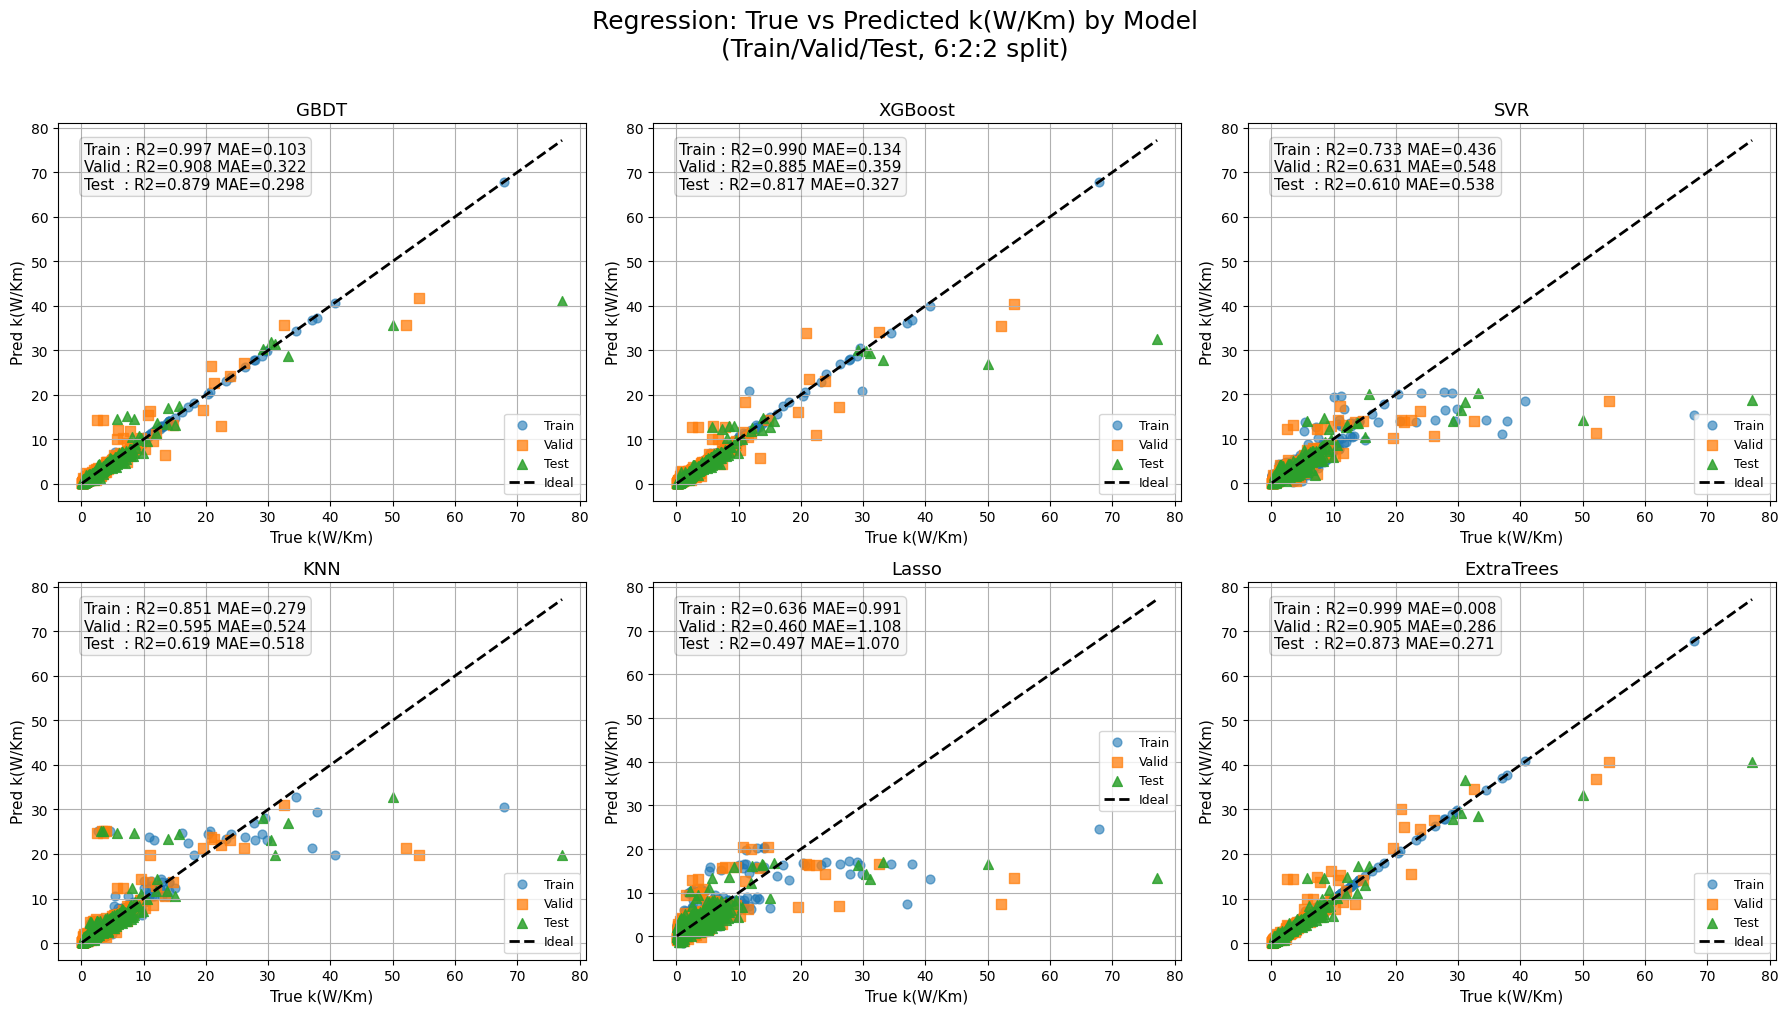


Train/Valid/Test set R2 and MAE summary (k(W/Km)):
GBDT            | Train R2: 0.9973, MAE: 0.1025 | Valid R2: 0.9079, MAE: 0.3217 | Test R2: 0.8795, MAE: 0.2979
XGBoost         | Train R2: 0.9900, MAE: 0.1337 | Valid R2: 0.8849, MAE: 0.3589 | Test R2: 0.8166, MAE: 0.3269
SVR             | Train R2: 0.7329, MAE: 0.4364 | Valid R2: 0.6311, MAE: 0.5479 | Test R2: 0.6097, MAE: 0.5382
KNN             | Train R2: 0.8507, MAE: 0.2786 | Valid R2: 0.5948, MAE: 0.5237 | Test R2: 0.6190, MAE: 0.5182
Lasso           | Train R2: 0.6356, MAE: 0.9908 | Valid R2: 0.4596, MAE: 1.1084 | Test R2: 0.4970, MAE: 1.0701
ExtraTrees      | Train R2: 0.9993, MAE: 0.0078 | Valid R2: 0.9054, MAE: 0.2864 | Test R2: 0.8730, MAE: 0.2705


In [9]:
# 设置全局随机种子，保证可复现性
import numpy as np
import random
np.random.seed(42)
random.seed(42)

import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
data = pd.read_csv('./data/character.csv')

# 仅使用ZT列之后的所有特征，列名为k(W/Km)的是目标，第一行是列名已自动处理
# 获取“ZT”所在列索引
zt_idx = list(data.columns).index('ZT')
# 特征为ZT列之后的所有列（直到最后一列）
feature_cols = data.columns[(zt_idx+1):]
# 目标列为k(W/Km)
X = data[feature_cols].values
y = data['k(W/Km)'].values

# 6:2:2 划分为训练集、验证集与测试集
from sklearn.model_selection import train_test_split
# 首先划分训练集(60%)与剩余(40%)
X_train, X_remain, y_train, y_remain = train_test_split(
    X, y, test_size=0.4, random_state=42, shuffle=True
)
# 再从剩余部分划分验证集(20%)和测试集(20%)
# 对于0.4的分割，1/2=0.5 即验证集、测试集各占剩余的50%
X_valid, X_test, y_valid, y_test = train_test_split(
    X_remain, y_remain, test_size=0.5, random_state=42, shuffle=True
)

# 标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# 构建模型
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso

models = {
    'GBDT'     : GradientBoostingRegressor(random_state=42),
    'XGBoost'  : XGBRegressor(random_state=42, verbosity=0),
    'SVR'      : SVR(),
    'KNN'      : KNeighborsRegressor(),
    'Lasso'    : Lasso(random_state=42, max_iter=10000),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
}

param_grids = {
    'GBDT': {
        'n_estimators': [100, 200],
        'max_depth': [3, 6],
        'learning_rate': [0.05, 0.1]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 6],
        'learning_rate': [0.05, 0.1]
    },
    'SVR': {
        'C': [1, 10],
        'gamma': ['scale', 'auto']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7]
    },
    'Lasso': {
        'alpha': [0.01, 0.1, 1.0]
    },
    'ExtraTrees': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20]
    }
}

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

best_models = {}
best_results = {}

for name, model in models.items():
    print(f'\n{name} 5-Fold CV and parameter search:')
    param_grid = param_grids[name]
    gs = GridSearchCV(
        model, param_grid, 
        cv=5, scoring='r2', 
        n_jobs=-1, verbose=0
    )
    gs.fit(X_train_scaled, y_train)
    best_models[name] = gs.best_estimator_
    means = gs.cv_results_['mean_test_score']
    stds = gs.cv_results_['std_test_score']
    for mean, std, params in zip(means, stds, gs.cv_results_['params']):
        print("R2: %0.4f (+/-%0.4f) for %r"
              % (mean, std * 2, params))
    print(f"Best params: {gs.best_params_}")
    print(f"Best CV R2: {gs.best_score_:.4f}")
    # 训练/验证/测试集预测
    y_train_pred = gs.predict(X_train_scaled)
    y_valid_pred = gs.predict(X_valid_scaled)
    y_test_pred = gs.predict(X_test_scaled)
    r2_train = r2_score(y_train, y_train_pred)
    r2_valid = r2_score(y_valid, y_valid_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_valid = mean_absolute_error(y_valid, y_valid_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    best_results[name] = {
        'r2_train': r2_train, 'r2_valid': r2_valid, 'r2_test': r2_test,
        'mae_train': mae_train, 'mae_valid': mae_valid, 'mae_test': mae_test,
        'y_train_pred': y_train_pred,
        'y_valid_pred': y_valid_pred,
        'y_test_pred': y_test_pred
    }

# 绘制六个模型的真实vs预测散点图在一张画布上
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()
for idx, (name, result) in enumerate(best_results.items()):
    y_train_pred = result['y_train_pred']
    y_valid_pred = result['y_valid_pred']
    y_test_pred = result['y_test_pred']
    r2_train = result['r2_train']
    r2_valid = result['r2_valid']
    r2_test = result['r2_test']
    mae_train = result['mae_train']
    mae_valid = result['mae_valid']
    mae_test = result['mae_test']
    ax = axs[idx]
    ax.scatter(
        y_train, y_train_pred,
        label='Train', alpha=0.60, s=40
    )
    ax.scatter(
        y_valid, y_valid_pred,
        label='Valid', marker='s', alpha=0.75, s=44
    )
    ax.scatter(
        y_test, y_test_pred,
        label='Test', marker='^', alpha=0.85, s=50
    )
    all_y = np.concatenate([y_train, y_valid, y_test])
    ax.plot(
        [all_y.min(), all_y.max()], [all_y.min(), all_y.max()],
        'k--', lw=2, label='Ideal'
    )
    textstr = (
        f"Train : R2={r2_train:.3f} MAE={mae_train:.3f}\n"
        f"Valid : R2={r2_valid:.3f} MAE={mae_valid:.3f}\n"
        f"Test  : R2={r2_test:.3f} MAE={mae_test:.3f}"
    )
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.16, facecolor='lightgrey'))
    ax.set_title(f"{name}", fontsize=13)
    ax.set_xlabel("True k(W/Km)", fontsize=11)
    ax.set_ylabel("Pred k(W/Km)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True)

# 如果子图多于所需要的，清除
for idx in range(len(models), len(axs)):
    fig.delaxes(axs[idx])

fig.suptitle("Regression: True vs Predicted k(W/Km) by Model\n(Train/Valid/Test, 6:2:2 split)", fontsize=18, y=1.01)
fig.tight_layout()
plt.show()

print("\nTrain/Valid/Test set R2 and MAE summary (k(W/Km)):")
for name, res in best_results.items():
    print(
        f"{name:15s} | "
        f"Train R2: {res['r2_train']:.4f}, MAE: {res['mae_train']:.4f} | "
        f"Valid R2: {res['r2_valid']:.4f}, MAE: {res['mae_valid']:.4f} | "
        f"Test R2: {res['r2_test']:.4f}, MAE: {res['mae_test']:.4f}"
    )
